## Support Vector Regression.

Use SVR when:

- Your dataset is small or medium-sized.
- The relationship is nonlinear.
- You want a smooth prediction function.
- You have many features.
- You are willing to scale the data and tune parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

In [2]:
data = {
    "age": [
        22, 25, 28, 30, 35, 40, 45, 32, 27, 50,
        24, 29, 33, 38, 42, 48, 26, 31, 36, 44,
        23, 34, 37, 41, 46, 28, 39, 43, 30, 47
    ],

    "experience": [
        1, 2, 4, 5, 10, 15, 20, 7, 3, 25,
        1, 5, 8, 12, 17, 22, 2, 6, 11, 18,
        1, 9, 13, 16, 21, 4, 14, 17, 6, 23
    ],

    # 1 = Bachelor, 2 = Master, 3 = PhD
    "education_level": [
        1, 1, 2, 2, 2, 3, 3, 2, 1, 3,
        1, 2, 2, 3, 3, 3, 1, 2, 2, 3,
        1, 2, 3, 3, 3, 2, 2, 3, 2, 3
    ],

    "projects": [
        2, 3, 6, 8, 15, 20, 30, 10, 4, 35,
        2, 7, 12, 18, 25, 32, 3, 9, 16, 28,
        2, 14, 19, 23, 31, 6, 21, 26, 10, 34
    ],

    # Salary in thousands
    "salary": [
        25, 30, 42, 50, 75, 100, 135, 62, 35, 160,
        27, 48, 68, 90, 115, 145, 32, 57, 80, 125,
        26, 72, 95, 108, 140, 43, 97, 120, 58, 150
    ]
}

df = pd.DataFrame(data)

df.head()

,age,experience,education_level,projects,salary
0,22,1,1,2,25
1,25,2,1,3,30
2,28,4,2,6,42
3,30,5,2,8,50
4,35,10,2,15,75


In [3]:
X = df.drop(columns=["salary"])
y = df["salary"]

print("Features:")
display(X.head())

print("\nTarget salary:")
display(y.head())

Features:


,age,experience,education_level,projects
0,22,1,1,2
1,25,2,1,3
2,28,4,2,6
3,30,5,2,8
4,35,10,2,15



Target salary:


0    25
1    30
2    42
3    50
4    75
Name: salary, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22
Testing samples: 8


In [5]:
model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "svr",
        SVR(
            kernel="rbf",
            C=100,
            epsilon=2,
            gamma="scale"
        )
    )
])

In [6]:
model.fit(X_train, y_train)

print("SVR training completed.")

SVR training completed.


In [7]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Salary (Thousands)": y_test.values,
    "Predicted Salary (Thousands)": y_pred
})

results

,Actual Salary (Thousands),Predicted Salary (Thousands)
0,120,118.991035
1,145,145.428821
2,108,108.535345
3,57,55.085428
4,35,32.847788
5,160,146.420885
6,58,54.249115
7,140,141.801425


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} thousand BDT")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} thousand BDT")
print(f"R²   : {r2:.4f}")

MAE  : 3.15 thousand BDT
MSE  : 26.44
RMSE : 5.14 thousand BDT
R²   : 0.9863


In [9]:
new_person = pd.DataFrame({
    "age": [34],
    "experience": [9],
    "education_level": [2],
    "projects": [14]
})

predicted_salary = model.predict(new_person)[0]

print(
    f"Predicted salary: "
    f"{predicted_salary * 1000:,.2f} BDT"
)

Predicted salary: 72,337.99 BDT


In [10]:
svr_model = model.named_steps["svr"]

support_vector_indexes = svr_model.support_

support_vector_rows = X_train.iloc[support_vector_indexes].copy()

support_vector_rows["salary"] = (
    y_train.iloc[support_vector_indexes].values
)

print("Number of training samples:", len(X_train))
print("Number of support vectors:", len(support_vector_indexes))

support_vector_rows

Number of training samples: 22
Number of support vectors: 9


,age,experience,education_level,projects,salary
0,22,1,1,2,25
4,35,10,2,15,75
16,26,2,1,3,32
22,37,13,3,19,95
2,28,4,2,6,42
26,39,14,2,21,97
29,47,23,3,34,150
7,32,7,2,10,62
6,45,20,3,30,135


Help on function plot in module matplotlib.pyplot:

plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs
) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.

    Call signatures::

        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

    The coordinates of the points or line nodes are given by *x*, *y*.

    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.

    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses

    You can use `.Line2D` properties as keyword arguments for more
    control on th

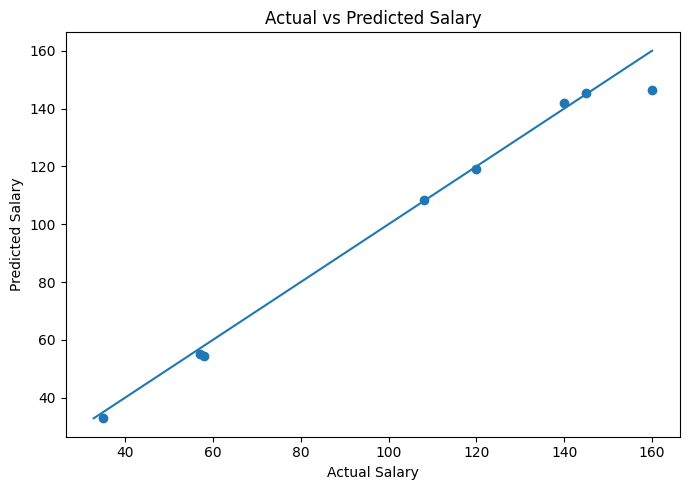

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="-"
)
help(plt.plot)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.tight_layout()
plt.show()